In [153]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, roc_auc_score, classification_report

In [154]:
sns.set_theme(style="whitegrid", palette="Greys_r")
plt.rcParams["figure.figsize"] = (12, 6)   
plt.rcParams["figure.dpi"] = 100

red_grey = mcolors.LinearSegmentedColormap.from_list(
    "RedGrey",
    ["#bfbfbf96", "#c60f0f"]  
)

In [215]:
def evaluate_model_with_shap(model, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, model_name: str = "Modelo", top_n: int = 10, shap_sample: int = 1000) -> float: 

    """
    Evaluate a binary classification model and generate SHAP explainability plots.

    Parameters
    ----------
    model : object
        Trained model supporting predict_proba.
    X_train : pd.DataFrame
    y_train : array-like
    X_test : pd.DataFrame
    y_test : array-like
    model_name : str
    top_n : int
    shap_sample : int

    Returns
    -------
    float
        ROC AUC score
    """

    # 🔹 Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # 🔹 Metrics
    print(f"\n=== {model_name} Evaluation ===")
    print(classification_report(y_test, y_pred))

    auc_score = roc_auc_score(y_test, y_proba)
    print(f"{model_name} AUC: {auc_score:.4f}")

    # 🔹 Feature Importance (XGBoost)
    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_
        }).sort_values("importance")

        imp.tail(top_n).plot.barh(x="feature", y="importance", figsize=(8,6))
        plt.title("Model Feature Importance")
        plt.grid(True)
        plt.show()

    # 🔹 SHAP
    print("\nCalculating SHAP values...")

    X_shap = X_test.sample(min(shap_sample, len(X_test)), random_state=42).astype(float)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # 🔥 GLOBAL IMPORTANCE (BAR)
    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="bar",
        max_display=top_n
    )

    # 🔥 IMPACT (DOT)
    plt.figure()
    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="dot",
        max_display=top_n
    )
    plt.title("SHAP Impact (Global)")
    plt.show()

    return auc_score


def _normalize_shap_values(shap_values, X: pd.DataFrame, class_idx: int = 0) -> np.ndarray:
    """
    Normalize SHAP values format for multiclass models.

    This function converts SHAP outputs into a consistent
    2D matrix (samples × features) for a selected class.

    Parameters
    ----------
    shap_values : array-like or list
        Raw SHAP values returned by the explainer.
    X : pd.DataFrame
        Dataset used to compute SHAP values.
    class_idx : int
        Index of the class to extract.

    Returns
    -------
    np.ndarray
        SHAP values matrix aligned with X.
    """
    if isinstance(shap_values, list):
        shap_values = shap_values[class_idx]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, class_idx]

    assert shap_values.shape == X.shape, (
        f"SHAP shape {shap_values.shape} != X shape {X.shape}"
    )

    return shap_values


def plot_global_shap_multiclass(raw_shap, X: pd.DataFrame, top_n: int = 10, class_names: tuple[str, str, str] = ("Class 0","Class 1","Class 2")) -> None:
    """
    Plot global SHAP feature importance for a multiclass model.

    This visualization aggregates mean absolute SHAP values and
    displays them as a stacked bar chart showing contribution
    per class.

    Parameters
    ----------
    raw_shap : array-like or list
        Raw SHAP values returned by the explainer.
    X : pd.DataFrame
        Dataset used for SHAP computation.
    top_n : int
        Number of top features displayed.
    class_names : tuple
        Names of the classes.
    """
    if isinstance(raw_shap, list):
        shap_array = np.stack(raw_shap, axis=2)
    else:
        shap_array = raw_shap

    mean_abs = np.mean(np.abs(shap_array), axis=0)


    if mean_abs.ndim == 1:
        total_importance = mean_abs
    else:
        total_importance = mean_abs.sum(axis=1)
        
    top_idx = np.argsort(total_importance)[-top_n:]

    features = X.columns[top_idx]
    values = mean_abs[top_idx]

    plt.figure(figsize=(12,6))

    bottom = np.zeros(len(top_idx))

    if values.ndim == 1:
        plt.barh(features, values)


    plt.xlabel("mean(|SHAP value|) (average impact magnitude)")
    plt.title("Global Feature Importance")
    plt.tight_layout()
    plt.show()


def shap_multiclass_full_report(
    model,
    X: pd.DataFrame,
    class_names=("Denied","Approved"),
    top_n: int = 10,
    sample_size: int = 1000
) -> None:

    X_shap = X.sample(min(sample_size, len(X)), random_state=42).astype(float)

    explainer = shap.TreeExplainer(model)
    raw_shap = explainer.shap_values(X_shap)

    # 🔥 CASO BINARIO
    if isinstance(raw_shap, np.ndarray):

        for i, name in enumerate(class_names):

            if name.lower() == "denied":
                shap_values = -raw_shap
            else:
                shap_values = raw_shap

            fig, axes = plt.subplots(
                1, 2,
                figsize=(12,6),
                gridspec_kw={"width_ratios": [2,1]}
            )

            fig.suptitle(f"Class: {name}", fontsize=12, fontweight="bold")

            # Impact
            plt.sca(axes[0])
            shap.summary_plot(
                shap_values,
                X_shap,
                plot_type="dot",
                max_display=top_n,
                cmap=red_grey,
                show=False
            )
            axes[0].set_title("SHAP Impact", fontsize=9)

            plt.sca(axes[1])
            shap.summary_plot(
                shap_values,
                X_shap,
                plot_type="bar",
                max_display=top_n,
                color="#6e6e6e",
                show=False
            )

            axes[1].set_yticklabels([])
            axes[1].set_ylabel("")
            axes[1].set_title("Feature Importance", fontsize=9)

            plt.tight_layout()
            plt.show()

        return

    plt.figure(figsize=(12,6))
    plot_global_shap_multiclass(raw_shap, X_shap, top_n=top_n, class_names=class_names)
    
def plot_probability_density(y_test: pd.Series | np.ndarray, proba: np.ndarray, model_name: str = "Modelo", class_names: tuple[str, str, str] = ("Denied","Approved")) -> None:
    """
    Plot kernel density estimation of predicted probabilities.

    This visualization shows how probability estimates differ
    across the true classes.

    Parameters
    ----------
    y_test : array-like
        True class labels.
    proba : np.ndarray
        Predicted class probabilities.
    model_name : str
        Model name used in the plot title.
    class_names : tuple
        Names of the classes.
    """
    y_test = np.array(y_test)

    plt.figure()

    if proba.ndim == 1:

        sns.kdeplot(
            proba[y_test == 0],
            fill=True,
            alpha=0.3,
            linewidth=2,
            label=class_names[0]
        )

        sns.kdeplot(
            proba[y_test == 1],
            fill=True,
            alpha=0.3,
            linewidth=2,
            label=class_names[1]
        )

    plt.title(f"Probability Density - {model_name}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_xgb_importance(model, X: pd.DataFrame, importance_type: str = "gain", top_n: int = 10) -> None:
    """
    Plot feature importance from an XGBoost model.

    The function extracts importance scores from the trained booster
    and displays the top features.

    Parameters
    ----------
    model : XGBoost model
        Trained XGBoost classifier or regressor.
    X : pd.DataFrame
        Dataset used for training (needed for feature names).
    importance_type : str
        Importance metric used by XGBoost (e.g., "gain", "weight", "cover").
    top_n : int
        Number of most important features displayed.
    """
    booster = model.get_booster()
    score = booster.get_score(importance_type=importance_type)

    imp = pd.DataFrame({
        "feature": list(score.keys()),
        "importance": list(score.values())
    })

    if all(f.startswith("f") for f in imp["feature"]):
        feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
        imp["feature"] = imp["feature"].map(feature_map)

    imp = imp.sort_values("importance").tail(top_n)

    plt.figure(figsize=(12,6))
    plt.barh(imp["feature"], imp["importance"])
    plt.xlabel(f"XGBoost Importance ({importance_type})")
    plt.title(f"Top {top_n} Features - {importance_type}")
    plt.tight_layout()
    plt.show()
    
def plot_correlation( cols : pd.DataFrame) -> None:

    corr_matrix = cols.corr()

    # Plot
    plt.figure(figsize=(12, 8))

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="Greys",     
        fmt=".2f",
        linewidths=0.5,
        cbar=True
    )

    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [156]:
data = pd.read_csv("dataset.csv")
data.head()

,Unnamed: 0,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,1,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
1,4,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
2,6,53,Employed,22.9,44989,674,11.1,19667,19298,0,0,0,Personal Loan,Home Improvement,45600,11.02,0.429,1.014,0.338,1
3,19,18,Self-Employed,1.0,55309,597,1.5,346,2930,0,0,0,Personal Loan,Debt Consolidation,50400,16.13,0.053,0.911,0.304,0
4,20,52,Employed,31.3,75932,695,2.1,1283,10655,0,0,0,Personal Loan,Home Improvement,96000,11.05,0.140,1.264,0.421,1


In [208]:
y = data["loan_status"]

X = data.drop(columns=["Unnamed: 0",'loan_status', 'interest_rate'])

X = pd.get_dummies(X, drop_first=True).astype(float)

X.head()


,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,...,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,occupation_status_Self-Employed,occupation_status_Student,loan_intent_Debt Consolidation,loan_intent_Education,loan_intent_Home Improvement,loan_intent_Medical,loan_intent_Personal
0,33.0,7.3,43087.0,627.0,3.5,169.0,16550.0,0.0,1.0,0.0,...,0.384,1.237,0.412,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,32.0,12.5,63657.0,630.0,7.2,209.0,12424.0,0.0,0.0,0.0,...,0.195,1.565,0.522,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,53.0,22.9,44989.0,674.0,11.1,19667.0,19298.0,0.0,0.0,0.0,...,0.429,1.014,0.338,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,18.0,1.0,55309.0,597.0,1.5,346.0,2930.0,0.0,0.0,0.0,...,0.053,0.911,0.304,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,52.0,31.3,75932.0,695.0,2.1,1283.0,10655.0,0.0,0.0,0.0,...,0.140,1.264,0.421,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [209]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17523 entries, 0 to 17522
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              17523 non-null  float64
 1   years_employed                   17523 non-null  float64
 2   annual_income                    17523 non-null  float64
 3   credit_score                     17523 non-null  float64
 4   credit_history_years             17523 non-null  float64
 5   savings_assets                   17523 non-null  float64
 6   current_debt                     17523 non-null  float64
 7   defaults_on_file                 17523 non-null  float64
 8   delinquencies_last_2yrs          17523 non-null  float64
 9   derogatory_marks                 17523 non-null  float64
 10  loan_amount                      17523 non-null  float64
 11  debt_to_income_ratio             17523 non-null  float64
 12  loan_to_income_rat

In [210]:
selected_features = [
    'credit_score',
    'debt_to_income_ratio',
    'credit_history_years',
    'years_employed',
    'payment_to_income_ratio',
    'loan_intent_Education',
    'delinquencies_last_2yrs',
    'defaults_on_file'
]

# Features
X = X[selected_features]

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=250,
    max_depth=2,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap_values_denied = -shap_values


print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1821
           1       0.82      0.87      0.84      1684

    accuracy                           0.84      3505
   macro avg       0.84      0.84      0.84      3505
weighted avg       0.85      0.84      0.84      3505

AUC: 0.9313717241838098


In [212]:
train_proba = model.predict_proba(X_train)[:,1]
test_proba = model.predict_proba(X_test)[:,1]

print("Train AUC:", roc_auc_score(y_train, train_proba))
print("Test AUC:", roc_auc_score(y_test, test_proba))

Train AUC: 0.9353184679970328
Test AUC: 0.9313717241838098


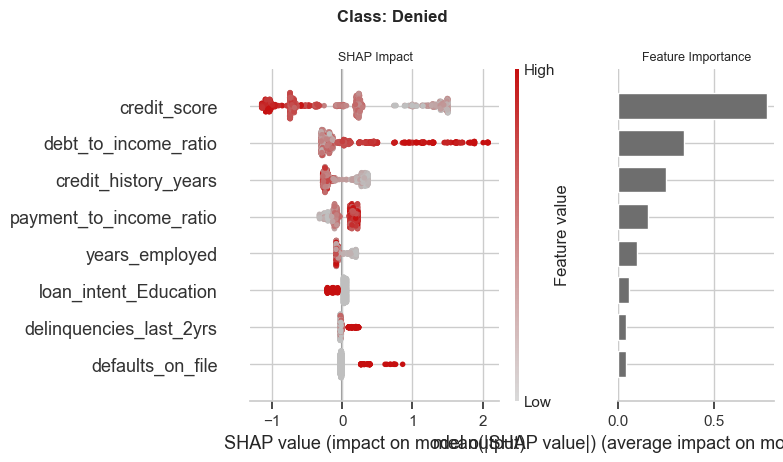

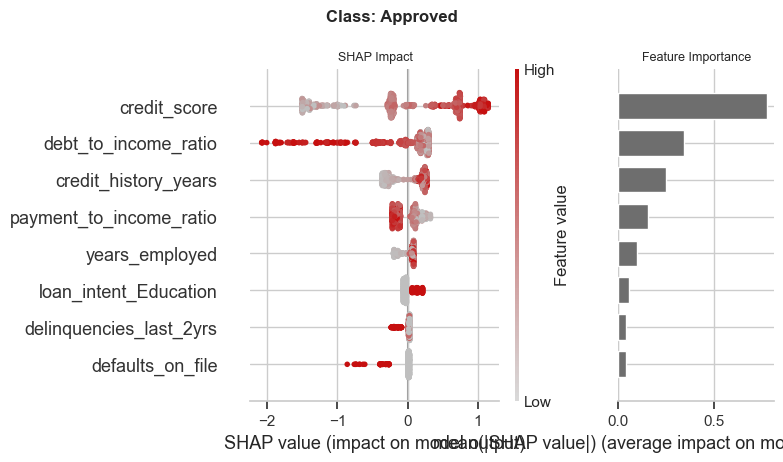

In [213]:
shap_multiclass_full_report(
    model=model,
    X=X_test,
    class_names=("Denied","Approved"),
    top_n=20,
    sample_size=1000,
)

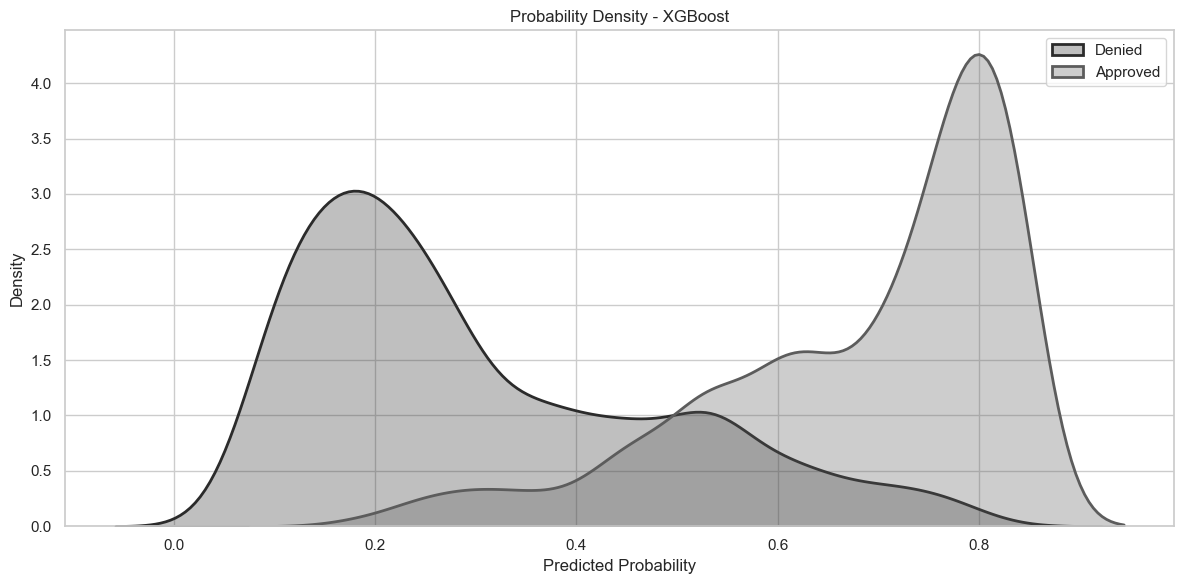

In [216]:
plot_probability_density(
    y_test,
    y_proba,
    model_name="XGBoost"
)

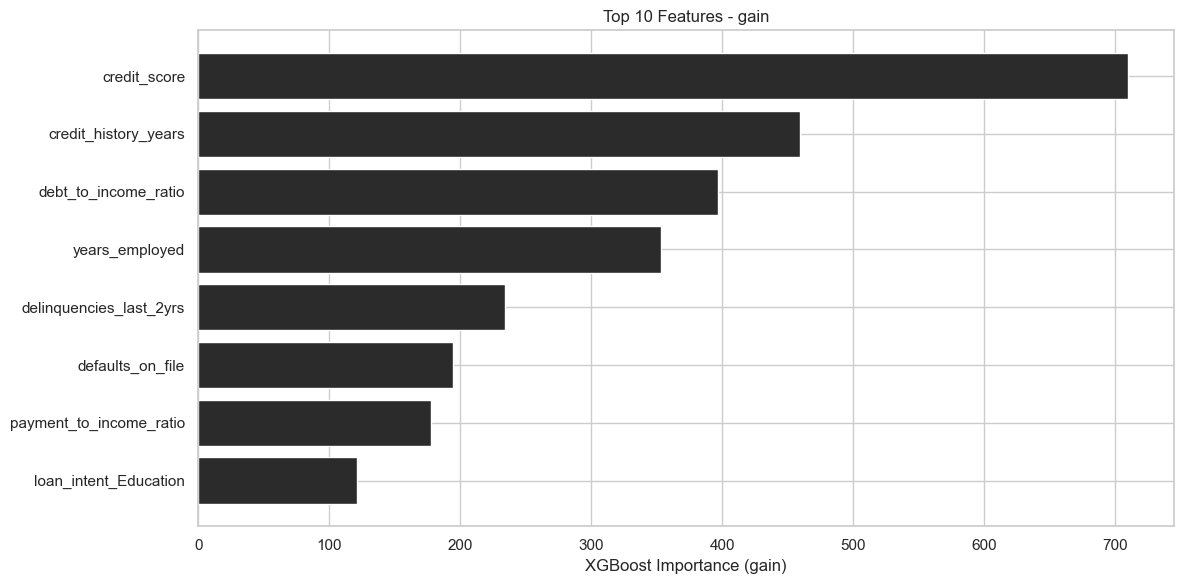

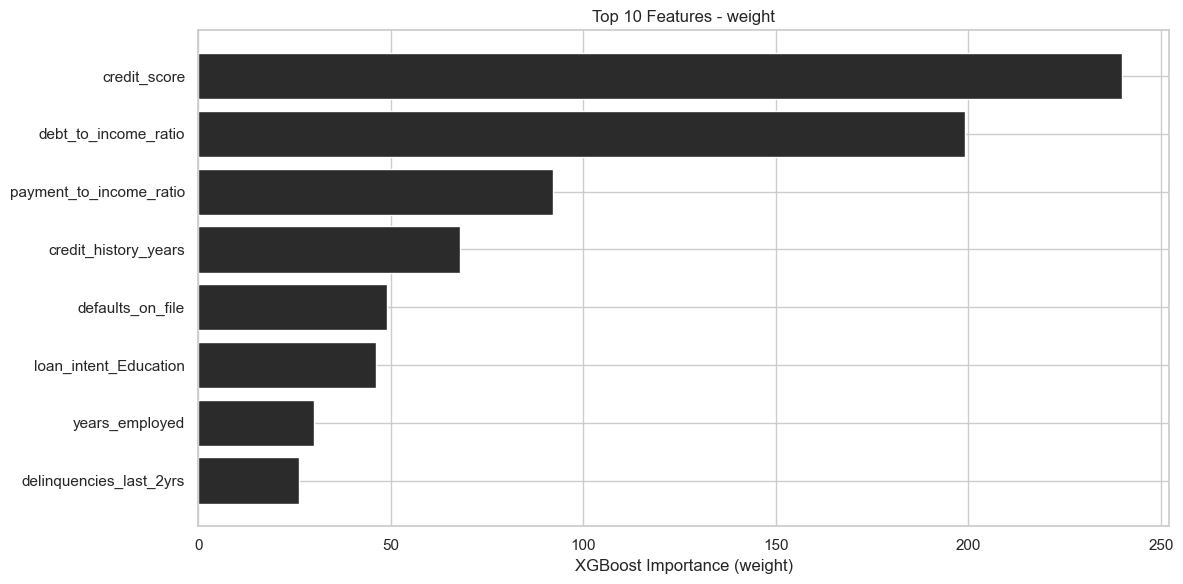

In [206]:
plot_xgb_importance(model, X_test, importance_type="gain")
plot_xgb_importance(model, X_test, importance_type="weight")

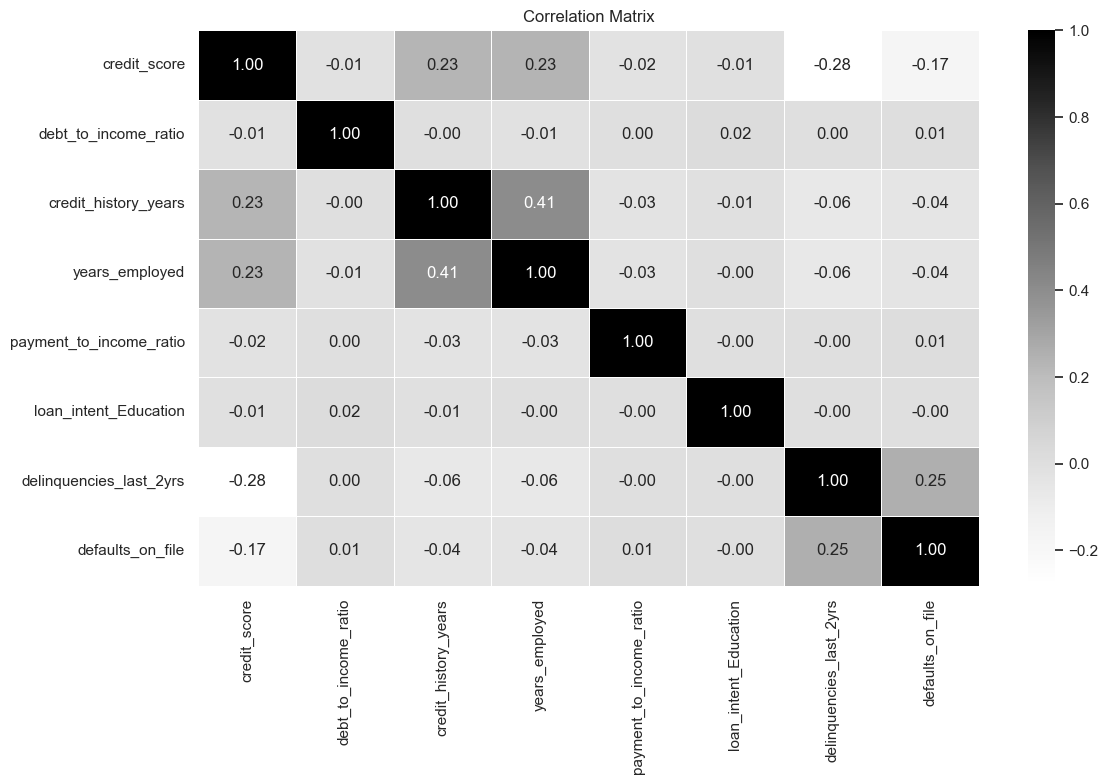

In [207]:
plot_correlation(cols=X[selected_features])